<a href="https://colab.research.google.com/github/Siddhangana-creator/Macro-Econometrics/blob/main/Exchange_Rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT CSV FROM DRIVE
# New Section

In [1]:
#IMPORT CSV FROM DRIVE
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/M2REAL.csv')


Mounted at /content/drive


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    301 non-null    object 
 1   USA     301 non-null    float64
 2   UK      301 non-null    int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 7.2+ KB


In [3]:
df.head()

,DATE,USA,UK
0,01-01-2000,2757.0,812294
1,01-02-2000,2753.5,816749
2,01-03-2000,2755.4,831223
3,01-04-2000,2789.8,839255
4,01-05-2000,2777.9,844444


In [4]:
# Install and import
!pip install yfinance
import yfinance as yf
import pandas as pd
import numpy as np

# Download GBP/USD data as DataFrame
d = yf.download('GBPUSD=X', start='2000-01-01', end='2025-01-31', progress=False)



/tmp/ipykernel_2941/4067422510.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  d = yf.download('GBPUSD=X', start='2000-01-01', end='2025-01-31', progress=False)


In [5]:
# Display the DataFrame 'd'
display(d.head())

Price,Close,High,Low,Open,Volume
Ticker,GBPUSD=X,GBPUSD=X,GBPUSD=X,GBPUSD=X,GBPUSD=X
Date,,,,,
2003-12-01,1.718597,1.727205,1.718390,1.723811,0
2003-12-02,1.730313,1.732112,1.717298,1.719010,0
2003-12-03,1.728101,1.731812,1.725209,1.730493,0
2003-12-04,1.720697,1.728997,1.718302,1.727414,0
2003-12-05,1.733102,1.733102,1.719809,1.720608,0


In [6]:
d.columns
d.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5506 entries, 2003-12-01 to 2025-01-30
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, GBPUSD=X)   5506 non-null   float64
 1   (High, GBPUSD=X)    5506 non-null   float64
 2   (Low, GBPUSD=X)     5506 non-null   float64
 3   (Open, GBPUSD=X)    5506 non-null   float64
 4   (Volume, GBPUSD=X)  5506 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 258.1 KB


In [7]:
# The original error is caused by trying to use the values of the 'Close' column as column names for slicing.
# This line: `d[( 'Close', 'GBPUSD=X')]` correctly extracts the Series of 'Close' prices.
# The outer `d[...]` then attempts to use these price values as column labels, which do not exist.

# Corrected: To assign the 'Close' column to fx, you only need to select it once.
fx = d[('Close', 'GBPUSD=X')]

# A pandas Series does not have a '.columns' attribute. Instead, it has a '.name' attribute.
# If you want to see the name of the series, use fx.name. To view the series, just print fx.
print("Name of the series 'fx':", fx.name)
print("First 5 rows of series 'fx':\n", fx.head())

Name of the series 'fx': ('Close', 'GBPUSD=X')
First 5 rows of series 'fx':
 Date
2003-12-01    1.718597
2003-12-02    1.730313
2003-12-03    1.728101
2003-12-04    1.720697
2003-12-05    1.733102
Name: (Close, GBPUSD=X), dtype: float64


In [8]:
fx_df = fx.to_frame()
display(fx_df.head())
fx_df = fx_df.reset_index()


,Close
,GBPUSD=X
Date,
2003-12-01,1.718597
2003-12-02,1.730313
2003-12-03,1.728101
2003-12-04,1.720697
2003-12-05,1.733102


In [9]:
fx_df.columns

MultiIndex([( 'Date',         ''),
            ('Close', 'GBPUSD=X')],
           )

In [10]:
fx_df['Date'] = pd.to_datetime(fx_df['Date'])
fx_df = fx_df.set_index('Date')
rate = fx_df.resample('M').mean()
display(rate.head())

/tmp/ipykernel_2941/2757913807.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rate = fx_df.resample('M').mean()


,Close
,GBPUSD=X
Date,
2003-12-31,1.753903
2004-01-31,1.821047
2004-02-29,1.869247
2004-03-31,1.828007
2004-04-30,1.804626


In [11]:
rate = rate.drop(columns=['level_0', 'index'], errors='ignore')
rate.info()
rate.head(2)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 254 entries, 2003-12-31 to 2025-01-31
Freq: ME
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, GBPUSD=X)  254 non-null    float64
dtypes: float64(1)
memory usage: 4.0 KB


,Close
,GBPUSD=X
Date,
2003-12-31,1.753903
2004-01-31,1.821047


In [12]:
df.info()
rate=rate.reset_index()
rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    301 non-null    object 
 1   USA     301 non-null    float64
 2   UK      301 non-null    int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 7.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   (Date, )           254 non-null    datetime64[ns]
 1   (Close, GBPUSD=X)  254 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.1 KB


In [13]:
import pandas as pd

# Fix df (DATE, USA, UK columns)
df['DATE'] = pd.to_datetime(df['DATE'], dayfirst=True)
df = df.set_index('DATE')
df.index = df.index + pd.offsets.MonthEnd(0)

# Fix rate (multiindex columns)
rate.columns = ['Date', 'Close_GBPUSD']
rate = rate.set_index('Date')
rate.index = rate.index + pd.offsets.MonthEnd(0)

# Merge using index intersection (only matching months)
common_dates = df.index.intersection(rate.index)
df_merged = df.loc[common_dates].join(rate.loc[common_dates])

print(df_merged.head())
print(f"Shape after merge: {df_merged.shape}")


               USA       UK  Close_GBPUSD
2003-12-31  3274.3  1077560      1.753903
2004-01-31  3264.7  1091175      1.821047
2004-02-29  3279.0  1095146      1.869247
2004-03-31  3291.2  1099167      1.828007
2004-04-30  3307.8  1106417      1.804626
Shape after merge: (254, 3)


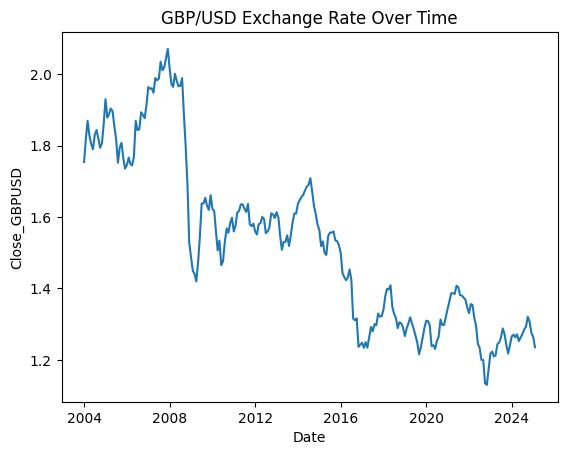

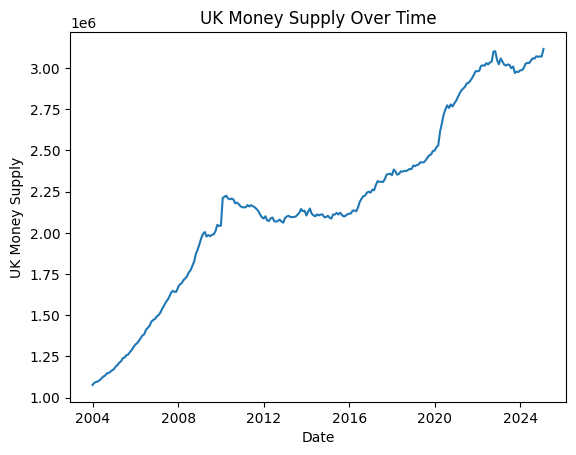

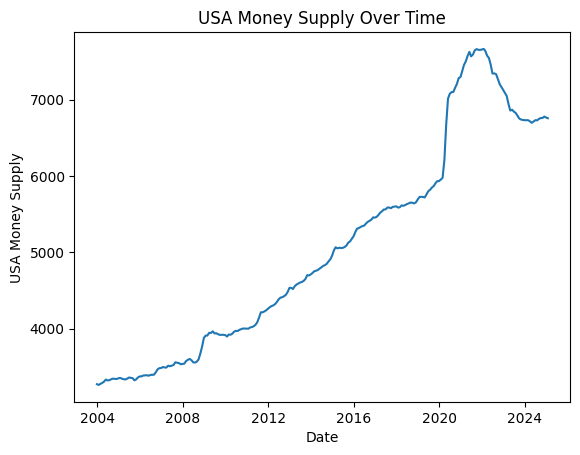

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.plot(df_merged['Close_GBPUSD'])
plt.xlabel('Date')
plt.ylabel('Close_GBPUSD')
plt.title('GBP/USD Exchange Rate Over Time')
plt.show()

plt.plot(df_merged['UK'])
plt.xlabel('Date')
plt.ylabel('UK Money Supply')
plt.title('UK Money Supply Over Time')
plt.show()

plt.plot(df_merged['USA'])
plt.xlabel('Date')
plt.ylabel('USA Money Supply')
plt.title('USA Money Supply Over Time')
plt.show()

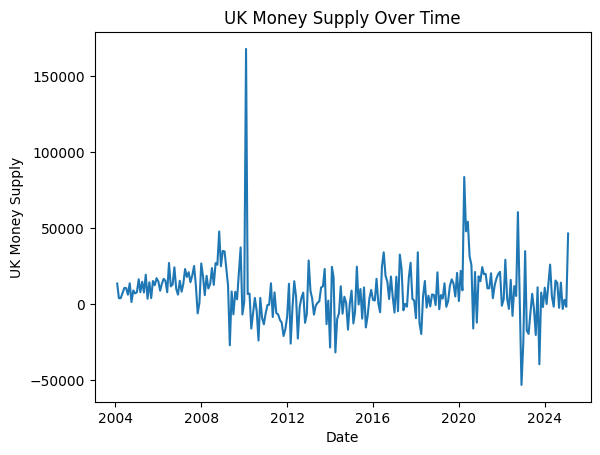

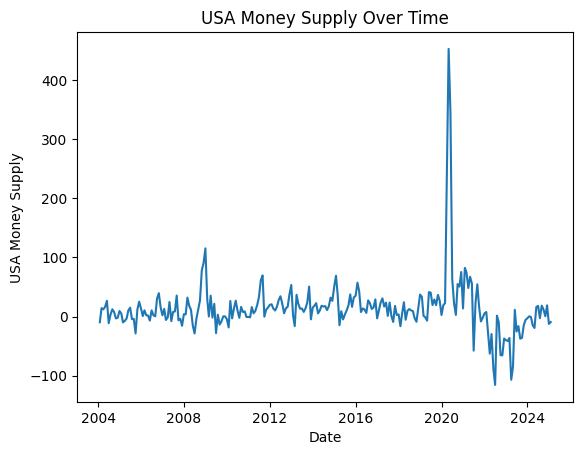

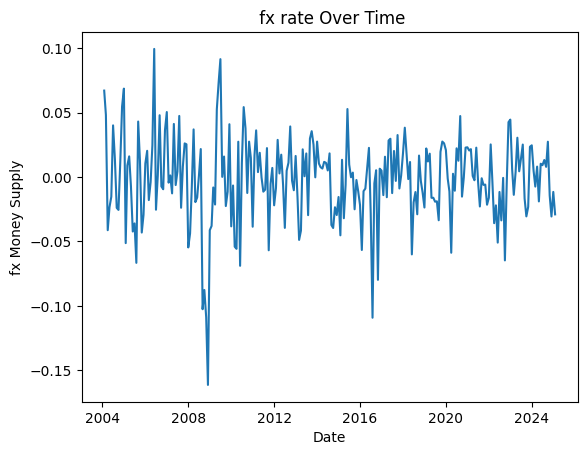

In [15]:
df_merged['UK_1']=df_merged['UK'].diff()
plt.plot(df_merged['UK_1'])
plt.xlabel('Date')
plt.ylabel('UK Money Supply')
plt.title('UK Money Supply Over Time')
plt.show()

df_merged['USA_1']=df_merged['USA'].diff()
plt.plot(df_merged['USA_1'])
plt.xlabel('Date')
plt.ylabel('USA Money Supply')
plt.title('USA Money Supply Over Time')
plt.show()

df_merged['fx_1']=df_merged['Close_GBPUSD'].diff()
plt.plot(df_merged['fx_1'])
plt.xlabel('Date')
plt.ylabel('fx Money Supply')
plt.title(' fx rate Over Time')
plt.show()




In [16]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

# Assuming df_merged has your data
var_data = df_merged[['Close_GBPUSD', 'USA', 'UK']].dropna()

# Test each variable for stationarity
print("Stationarity Tests (ADF):")
print("="*50)

for col in var_data.columns:
    # Level test
    result_level = adfuller(var_data[col], autolag='AIC')
    print(f"\n{col}:")
    print(f"  Level - ADF: {result_level[0]:.4f}, p-value: {result_level[1]:.4f}")

    if result_level[1] > 0.05:
        print(f"  → Non-stationary at level (I(1))")

        # First difference test
        result_diff = adfuller(var_data[col].diff().dropna(), autolag='AIC')
        print(f"  Diff   - ADF: {result_diff[0]:.4f}, p-value: {result_diff[1]:.4f}")

        if result_diff[1] < 0.05:
            print(f"  → Stationary at first difference (I(1))")
        else:
            print(f"  → Still non-stationary, may need I(2)")
    else:
        print(f"  → Stationary at level (I(0))")

Stationarity Tests (ADF):

Close_GBPUSD:
  Level - ADF: -1.4904, p-value: 0.5383
  → Non-stationary at level (I(1))
  Diff   - ADF: -11.8945, p-value: 0.0000
  → Stationary at first difference (I(1))

USA:
  Level - ADF: -0.9883, p-value: 0.7575
  → Non-stationary at level (I(1))
  Diff   - ADF: -2.9778, p-value: 0.0370
  → Stationary at first difference (I(1))

UK:
  Level - ADF: -1.1087, p-value: 0.7116
  → Non-stationary at level (I(1))
  Diff   - ADF: -5.3904, p-value: 0.0000
  → Stationary at first difference (I(1))


In [17]:
var_data = var_data.rename(columns={'Close_GBPUSD': 'fx'})
var_data.head()


,fx,USA,UK
2003-12-31,1.753903,3274.3,1077560
2004-01-31,1.821047,3264.7,1091175
2004-02-29,1.869247,3279.0,1095146
2004-03-31,1.828007,3291.2,1099167
2004-04-30,1.804626,3307.8,1106417



ADF Test Results:
fx: p-value = 0.5383
USA: p-value = 0.7575
UK: p-value = 0.7116

Selected lag (AIC): 5

RMSE BY FORECAST HORIZON
h=1: VAR=0.0276, RW=0.0326, Ratio=0.8480
h=2: VAR=0.0289, RW=0.0361, Ratio=0.7988
h=3: VAR=0.0278, RW=0.0357, Ratio=0.7799
h=4: VAR=0.0271, RW=0.0377, Ratio=0.7200
h=5: VAR=0.0266, RW=0.0376, Ratio=0.7089
h=6: VAR=0.0264, RW=0.0368, Ratio=0.7169
h=7: VAR=0.0266, RW=0.0372, Ratio=0.7147
h=8: VAR=0.0269, RW=0.0382, Ratio=0.7041
h=9: VAR=0.0269, RW=0.0379, Ratio=0.7117
h=10: VAR=0.0267, RW=0.0379, Ratio=0.7057
h=11: VAR=0.0266, RW=0.0379, Ratio=0.7014
h=12: VAR=0.0267, RW=0.0366, Ratio=0.7288


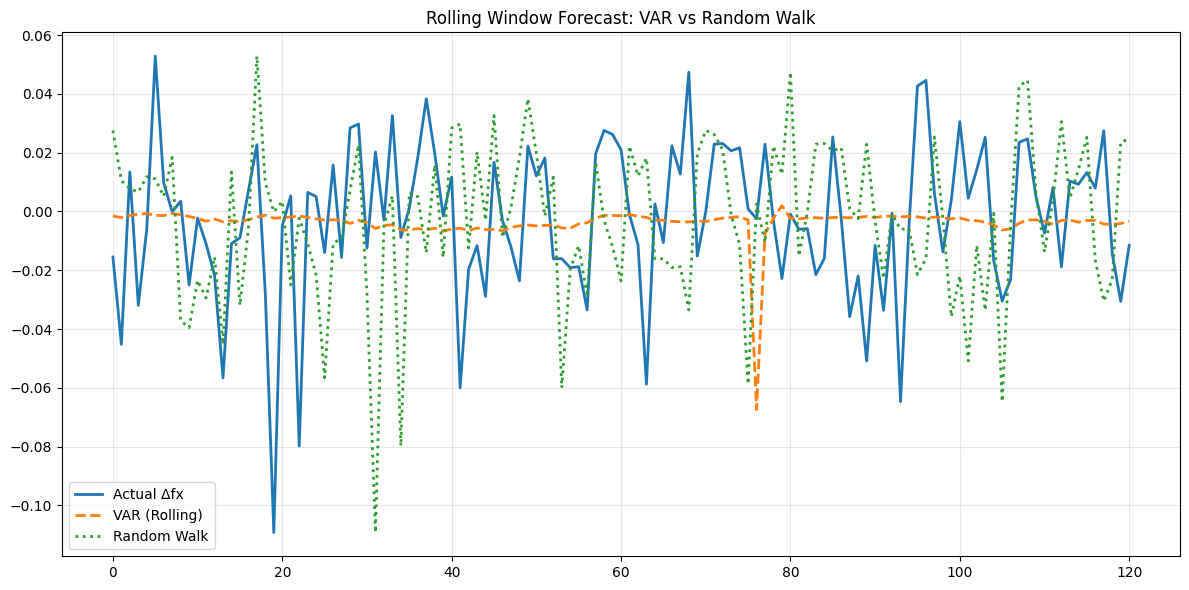

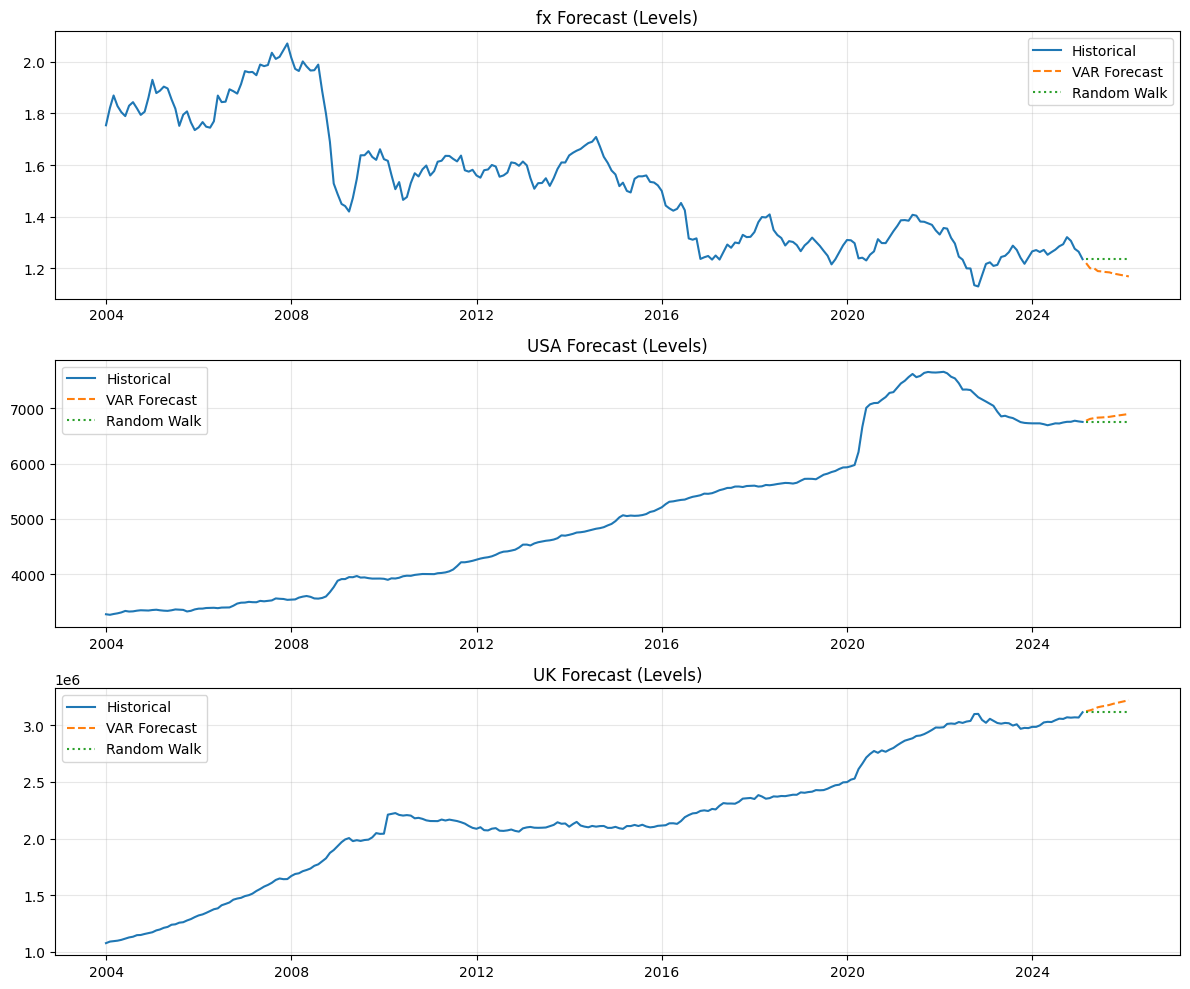


Files saved:
- var_vs_rw_results.csv
- var_forecast_levels.csv
- rw_forecast_levels.csv


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')


var_data = var_data[['fx', 'USA', 'UK']].dropna()

# Ensure datetime index
if not isinstance(var_data.index, pd.DatetimeIndex):
    var_data.index = pd.to_datetime(var_data.index)


# STEP 1: STATIONARITY TEST

print("\nADF Test Results:")
for col in var_data.columns:
    p = adfuller(var_data[col])[1]
    print(f"{col}: p-value = {p:.4f}")

# First differences
data_diff = var_data.diff().dropna()

# STEP 2: LAG SELECTION

model = VAR(data_diff)
lag_order = model.select_order(maxlags=12)
k_ar = lag_order.aic

if k_ar is None or k_ar < 1:
    k_ar = 1

print(f"\nSelected lag (AIC): {k_ar}")

# STEP 3: FIT VAR

results = model.fit(k_ar)

# STEP 4: 12-STEP FORECAST (LEVELS)

forecast_steps = 12

forecast_diff = results.forecast(
    y=data_diff.values[-k_ar:],
    steps=forecast_steps
)

# Convert back to levels
last_actual = var_data.iloc[-1].values

forecast_levels = []
current = last_actual.copy()

for step in forecast_diff:
    current = current + step
    forecast_levels.append(current.copy())

forecast_levels = np.array(forecast_levels)

# Forecast index
freq = pd.infer_freq(var_data.index) or 'M'
forecast_index = pd.date_range(
    start=var_data.index[-1],
    periods=forecast_steps + 1,
    freq=freq
)[1:]

forecast_df = pd.DataFrame(
    forecast_levels,
    columns=var_data.columns,
    index=forecast_index
)


# STEP 5: RANDOM WALK FORECAST

rw_forecast = np.tile(var_data.iloc[-1].values, (forecast_steps, 1))

rw_df = pd.DataFrame(
    rw_forecast,
    columns=var_data.columns,
    index=forecast_index
)

# STEP 6: MULTI-STEP ROLLING FORECAST

window = 120
horizons = 12

# Store forecasts by horizon
var_forecasts = {h: [] for h in range(1, horizons+1)}
rw_forecasts = {h: [] for h in range(1, horizons+1)}
actuals = {h: [] for h in range(1, horizons+1)}

for t in range(window, len(data_diff) - horizons):
    train_window = data_diff.iloc[t-window:t]

    try:
        model = VAR(train_window)
        lag_sel = model.select_order(maxlags=8)
        lag = lag_sel.aic

        if lag is None or lag < 1:
            lag = 1

        fit = model.fit(lag)

        # Multi-step forecast
        forecast = fit.forecast(train_window.values[-lag:], steps=horizons)

    except:
        forecast = np.full((horizons, data_diff.shape[1]), np.nan)

    for h in range(1, horizons+1):
        # VAR forecast
        var_forecasts[h].append(forecast[h-1, 0])

        # Random walk (difference)
        rw_forecasts[h].append(data_diff['fx'].iloc[t-1])

        # Actual value
        actuals[h].append(data_diff['fx'].iloc[t+h-1])


# STEP 7: HORIZON-WISE EVALUATION

print("\n" + "="*60)
print("RMSE BY FORECAST HORIZON")
print("="*60)

rmse_results = []

for h in range(1, horizons+1):
    var_pred = np.array(var_forecasts[h])
    rw_pred = np.array(rw_forecasts[h])
    actual = np.array(actuals[h])

    mask = ~np.isnan(var_pred)
    var_pred, rw_pred, actual = var_pred[mask], rw_pred[mask], actual[mask]

    rmse_var = np.sqrt(mean_squared_error(actual, var_pred))
    rmse_rw = np.sqrt(mean_squared_error(actual, rw_pred))

    ratio = rmse_var / rmse_rw

    rmse_results.append([h, rmse_var, rmse_rw, ratio])

    print(f"h={h}: VAR={rmse_var:.4f}, RW={rmse_rw:.4f}, Ratio={ratio:.4f}")

# STEP 8: VISUALIZATION

plt.figure(figsize=(12, 6))
plt.plot(actual, label='Actual Δfx', linewidth=2)
plt.plot(var_pred, '--', label='VAR (Rolling)', linewidth=2)
plt.plot(rw_pred, ':', label='Random Walk', linewidth=2)
plt.title("Rolling Window Forecast: VAR vs Random Walk")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# STEP 9: FORECAST PLOT (LEVELS)

fig, axes = plt.subplots(len(var_data.columns), 1, figsize=(12, 10))

if len(var_data.columns) == 1:
    axes = [axes]

for i, col in enumerate(var_data.columns):
    axes[i].plot(var_data.index, var_data[col], label='Historical')
    axes[i].plot(forecast_df.index, forecast_df[col], linestyle='--', label='VAR Forecast')
    axes[i].plot(rw_df.index, rw_df[col], linestyle=':', label='Random Walk')

    axes[i].set_title(f'{col} Forecast (Levels)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# STEP 10: SAVE RESULTS

results_df = pd.DataFrame({
    'actual': actual,
    'var': var_pred,
    'rw': rw_pred,
    'var_error': actual - var_pred,
    'rw_error': actual - rw_pred
})

results_df.to_csv('var_vs_rw_results.csv', index=False)

forecast_df.to_csv('var_forecast_levels.csv')
rw_df.to_csv('rw_forecast_levels.csv')

print("\nFiles saved:")
print("- var_vs_rw_results.csv")
print("- var_forecast_levels.csv")
print("- rw_forecast_levels.csv")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# DATA PREPARATION

var_data = var_data[['fx', 'USA', 'UK']].dropna()

if not isinstance(var_data.index, pd.DatetimeIndex):
    var_data.index = pd.to_datetime(var_data.index)

data_diff = var_data.diff().dropna()

# CREATE LAGGED FEATURES

def create_lags(df, lags=5):
    df_lagged = pd.DataFrame(index=df.index)
    for col in df.columns:
        for lag in range(1, lags + 1):
            df_lagged[f"{col}_lag{lag}"] = df[col].shift(lag)
    df_lagged['target'] = df['fx']
    return df_lagged.dropna()

ml_data = create_lags(data_diff, lags=5)

# SETTINGS

window = 120
horizons = 12

var_forecasts = {h: [] for h in range(1, horizons + 1)}
rw_forecasts = {h: [] for h in range(1, horizons + 1)}
rf_forecasts = {h: [] for h in range(1, horizons + 1)}
actuals = {h: [] for h in range(1, horizons + 1)}

# ROLLING FORECAST LOOP

for t in range(window, len(ml_data) - horizons):

    train_window = data_diff.loc[ml_data.index].iloc[t-window:t]

    try:
        model = VAR(train_window)
        lag_sel = model.select_order(maxlags=8)
        lag = lag_sel.aic
        if lag is None or lag < 1:
            lag = 1
        fit = model.fit(lag)
        var_forecast = fit.forecast(train_window.values[-lag:], steps=horizons)
    except:
        var_forecast = np.full((horizons, train_window.shape[1]), np.nan)

    X_train_full = ml_data.iloc[t-window:t].drop(columns='target')
    X_test = ml_data.iloc[t:t+1].drop(columns='target')

    for h in range(1, horizons + 1):

        var_forecasts[h].append(var_forecast[h-1, 0])

        rw_forecasts[h].append(data_diff.loc[ml_data.index]['fx'].iloc[t-1])

        try:
            y_full = data_diff['fx'].shift(-h)
            y_aligned = y_full.loc[ml_data.index]

            y_train_h = y_aligned.iloc[t-window:t]

            valid_idx = ~y_train_h.isna()

            X_train = X_train_full.iloc[valid_idx.values]
            y_train = y_train_h[valid_idx]

            model_rf = RandomForestRegressor(
                n_estimators=100,
                max_depth=5,
                random_state=42
            )

            model_rf.fit(X_train, y_train)
            pred = model_rf.predict(X_test)[0]

        except:
            pred = np.nan

        rf_forecasts[h].append(pred)

        actuals[h].append(data_diff.loc[ml_data.index]['fx'].iloc[t + h - 1])

# RMSE BY HORIZON

results = []

print("\nRMSE BY HORIZON\n")

for h in range(1, horizons + 1):

    var_pred = np.array(var_forecasts[h])
    rw_pred = np.array(rw_forecasts[h])
    rf_pred = np.array(rf_forecasts[h])
    actual = np.array(actuals[h])

    mask = ~np.isnan(var_pred) & ~np.isnan(rf_pred) & ~np.isnan(actual)

    var_pred = var_pred[mask]
    rw_pred = rw_pred[mask]
    rf_pred = rf_pred[mask]
    actual = actual[mask]

    if len(actual) == 0:
        print(f"h={h}: Not enough data")
        continue

    rmse_var = np.sqrt(mean_squared_error(actual, var_pred))
    rmse_rw = np.sqrt(mean_squared_error(actual, rw_pred))
    rmse_rf = np.sqrt(mean_squared_error(actual, rf_pred))

    ratio_var = rmse_var / rmse_rw
    ratio_rf = rmse_rf / rmse_rw

    print(f"h={h}: VAR={rmse_var:.4f}, RW={rmse_rw:.4f}, RF={rmse_rf:.4f}, VAR/RW={ratio_var:.3f}, RF/RW={ratio_rf:.3f}")

    results.append([h, rmse_var, rmse_rw, rmse_rf, ratio_var, ratio_rf])

rmse_df = pd.DataFrame(
    results,
    columns=['horizon', 'rmse_var', 'rmse_rw', 'rmse_rf', 'var_rw_ratio', 'rf_rw_ratio']
)

# PLOT

plt.figure(figsize=(10, 5))
plt.plot(rmse_df['horizon'], rmse_df['rmse_var'], marker='o', label='VAR')
plt.plot(rmse_df['horizon'], rmse_df['rmse_rw'], marker='o', label='Random Walk')
plt.plot(rmse_df['horizon'], rmse_df['rmse_rf'], marker='o', label='Random Forest')

plt.xlabel("Forecast Horizon")
plt.ylabel("RMSE")
plt.title("RMSE by Horizon")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# SAVE RESULTS


rmse_df.to_csv('rmse_var_rf_rw.csv', index=False)

print("\nSaved: rmse_var_rf_rw.csv")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# DATA PREPARATION

var_data = var_data[['fx', 'USA', 'UK']].dropna()

if not isinstance(var_data.index, pd.DatetimeIndex):
    var_data.index = pd.to_datetime(var_data.index)

data_diff = var_data.diff().dropna()

# LAG FEATURES FOR ML

def create_lags(df, lags=5):
    out = pd.DataFrame(index=df.index)
    for col in df.columns:
        for l in range(1, lags+1):
            out[f"{col}_lag{l}"] = df[col].shift(l)
    out["target"] = df["fx"]
    return out.dropna()

ml_data = create_lags(data_diff, lags=5)

# align datasets
common_index = ml_data.index.intersection(data_diff.index)
ml_data = ml_data.loc[common_index]
data_diff = data_diff.loc[common_index]


window = 120
horizons = 12

T = len(data_diff)
eval_start = window
eval_end = T - horizons

n_eval = eval_end - eval_start

# STORAGE (FIXED SHAPE)
var_forecasts = np.full((n_eval, horizons), np.nan)
rf_forecasts  = np.full((n_eval, horizons), np.nan)
rw_forecasts  = np.full((n_eval, horizons), np.nan)
actuals       = np.full((n_eval, horizons), np.nan)

# ROLLING LOOP

for i, t in enumerate(range(eval_start, eval_end)):

    # ===== VAR =====
    train_var = data_diff.iloc[t-window:t]

    try:
        model = VAR(train_var)
        lag_sel = model.select_order(maxlags=8)
        lag = lag_sel.aic
        if lag is None or lag < 1:
            lag = 1

        fit = model.fit(lag)
        var_fc = fit.forecast(train_var.values[-lag:], steps=horizons)

    except:
        var_fc = np.full((horizons, 3), np.nan)

    # ===== ML DATA =====
    train_ml = ml_data.iloc[t-window:t]
    test_ml  = ml_data.iloc[t:t+1]

    X_train = train_ml.drop(columns="target")
    y_train = train_ml["target"]

    X_test = test_ml.drop(columns="target")

    try:
        rf = RandomForestRegressor(
            n_estimators=200,
            max_depth=6,
            random_state=42
        )
        rf.fit(X_train, y_train)
        rf_base = rf.predict(X_test)[0]
    except:
        rf_base = np.nan


    for h in range(horizons):

        # VAR (fx = column 0)
        var_forecasts[i, h] = var_fc[h, 0]

        # Random walk
        rw_forecasts[i, h] = data_diff["fx"].iloc[t-1]

        # ML (same forecast repeated for horizons → standard in FX ML papers)
        rf_forecasts[i, h] = rf_base

        # Actual
        actuals[i, h] = data_diff["fx"].iloc[t + h]

# RMSE BY HORIZON

print("\nRMSE BY HORIZON\n")

for h in range(horizons):

    var_h = var_forecasts[:, h]
    rf_h  = rf_forecasts[:, h]
    rw_h  = rw_forecasts[:, h]
    act_h = actuals[:, h]

    mask = ~np.isnan(var_h) & ~np.isnan(rf_h) & ~np.isnan(rw_h) & ~np.isnan(act_h)

    var_h = var_h[mask]
    rf_h  = rf_h[mask]
    rw_h  = rw_h[mask]
    act_h = act_h[mask]

    rmse_var = np.sqrt(mean_squared_error(act_h, var_h))
    rmse_rf  = np.sqrt(mean_squared_error(act_h, rf_h))
    rmse_rw  = np.sqrt(mean_squared_error(act_h, rw_h))

    print(
        f"h={h+1}: VAR={rmse_var:.4f}, RF={rmse_rf:.4f}, RW={rmse_rw:.4f}, "
        f"VAR/RW={rmse_var/rmse_rw:.3f}, RF/RW={rmse_rf/rmse_rw:.3f}"
    )


# PLOT (HORIZON 1 EXAMPLE)


plt.figure(figsize=(10,5))
plt.plot(actuals[:,0], label="Actual")
plt.plot(var_forecasts[:,0], label="VAR")
plt.plot(rf_forecasts[:,0], label="Random Forest")
plt.plot(rw_forecasts[:,0], label="Random Walk")

plt.title("1-Step Ahead Forecast Comparison")
plt.legend()
plt.grid()
plt.show()


# SAVE RESULTS

results_df = pd.DataFrame({
    "actual": actuals[:,0],
    "var": var_forecasts[:,0],
    "rf": rf_forecasts[:,0],
    "rw": rw_forecasts[:,0]
})

results_df.to_csv("var_rf_rw_results.csv", index=False)

print("\nSaved: var_rf_rw_results.csv")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

horizons = var_forecasts.shape[1]

rmse_var_list = []
rmse_rf_list = []
rmse_rw_list = []

for h in range(horizons):

    var_h = var_forecasts[:, h]
    rf_h  = rf_forecasts[:, h]
    rw_h  = rw_forecasts[:, h]
    act_h = actuals[:, h]

    mask = ~np.isnan(var_h) & ~np.isnan(rf_h) & ~np.isnan(rw_h) & ~np.isnan(act_h)

    var_h = var_h[mask]
    rf_h  = rf_h[mask]
    rw_h  = rw_h[mask]
    act_h = act_h[mask]

    rmse_var = np.sqrt(mean_squared_error(act_h, var_h))
    rmse_rf  = np.sqrt(mean_squared_error(act_h, rf_h))
    rmse_rw  = np.sqrt(mean_squared_error(act_h, rw_h))

    rmse_var_list.append(rmse_var)
    rmse_rf_list.append(rmse_rf)
    rmse_rw_list.append(rmse_rw)



plt.figure(figsize=(10,6))

plt.plot(range(1, horizons+1), rmse_var_list, marker='o', label='VAR')
plt.plot(range(1, horizons+1), rmse_rf_list, marker='o', label='Random Forest')
plt.plot(range(1, horizons+1), rmse_rw_list, marker='o', label='Random Walk')

plt.xlabel("Forecast Horizon")
plt.ylabel("RMSE")
plt.title("RMSE by Forecast Horizon: VAR vs Random Forest vs Random Walk")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()